# hough transform
The Hough transform is a feature extraction technique used in image analysis, computer vision, and digitalimage processing. It is particularly useful for detecting simple shapes such as lines, circles, and ellipses in images. The Hough transform works by transforming the image space into a parameter space, where each point in the parameter space corresponds to a potential shape in the image.

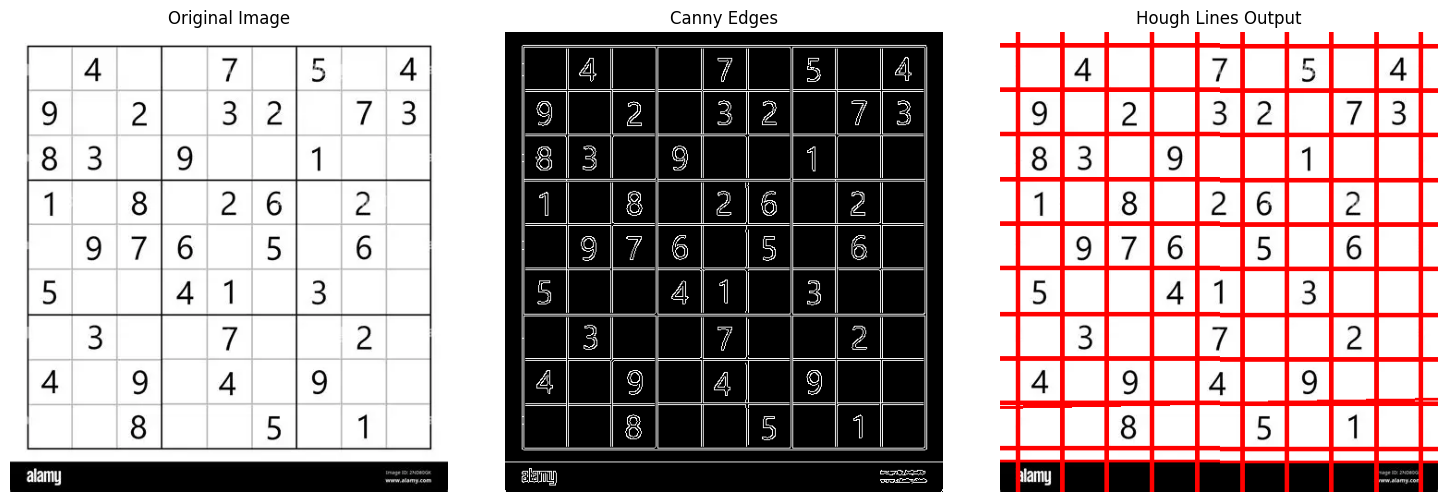

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = r"D:\UMEF\E1402_Digital and Computer Vision\session5\soduku.jpg"
image = cv2.imread(img_path)

if image is None:
    raise FileNotFoundError(f"Could not read image at: {img_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)

output = image.copy()
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        x1, y1 = int(x0 + 1000 * (-b)), int(y0 + 1000 * a)
        x2, y2 = int(x0 - 1000 * (-b)), int(y0 - 1000 * a)
        cv2.line(output, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Convert BGR -> RGB for matplotlib
orig_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
out_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(orig_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(out_rgb)
plt.title("Hough Lines Output")
plt.axis("off")

plt.tight_layout()
plt.show()
